# Superstore Analysis
## Explorative Data Analysis
* **Goal:** TBA

In [81]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [82]:
# Safe data loading with try/except
file_path = '../data/superstore.csv'

try:
    df = pd.read_csv(file_path, encoding='latin1')
    print(f'Data loaded successfully')
except FileNotFoundError:
    print(f'File not found - check {file_path}')
except Exception as e:
    print(f'Unexpected error occurred - check {e}')

Data loaded successfully


In [83]:
# First inspection of Dataset with df.info()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [84]:
# View the head of the dataset
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [85]:
# Inspect the Statistic Metrics of Dataset
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [86]:
# Check columns of the dataset
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [87]:
# Checking for missing values
df.isna().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [88]:
# Check for duplicates
df.duplicated().sum()

np.int64(0)

**Observation:** The dataset contains no missing values and no duplicate records.
However, the descriptive statistics reveal unusually low profit values, with a minimum profit of -$6,599.98. This will be investigated further to determine whether these losses are caused by discounts, specific products, or other business factors.

In [89]:
# Convert 'Order Date' and 'Ship Date' into pandas datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%m/%d/%Y')

# Check the type for both
print(df['Order Date'].dtype)
print(df['Ship Date'].dtype)


datetime64[ns]
datetime64[ns]


In [90]:
df[['Order Date', 'Ship Date']].head()

,Order Date,Ship Date
0,2016-11-08,2016-11-11
1,2016-11-08,2016-11-11
2,2016-06-12,2016-06-16
3,2015-10-11,2015-10-18
4,2015-10-11,2015-10-18


In [91]:
# Convert 'Postal Code' into string
df['Postal Code'] = df['Postal Code'].astype(str).str.zfill(5)

# Check for dtype of 'Postal Code'
print(df['Postal Code'].dtype)

object


In [92]:
df['Postal Code'].head()

0    42420
1    42420
2    90036
3    33311
4    33311
Name: Postal Code, dtype: object

**Data Type Adjustments:**
- Converted Order Date and Ship Date to datetime format.
- Converted Postal Code to string format to preserve leading zeros.

In [93]:
# First analysis of most comun category
print(df.groupby('Category')['Sales'].agg(['count', 'sum', 'mean']).sort_values(by='sum', ascending=False).round(2))

                 count        sum    mean
Category                                 
Technology        1847  836154.03  452.71
Furniture         2121  741999.80  349.83
Office Supplies   6026  719047.03  119.32


**Analysis:**  
The analysis shows that **Office Supplies** has the highest number of transactions, while **Technology** generates the highest total revenue despite having fewer transactions. This indicates that Technology products have a significantly higher average sales value per order.

**Recommendation:**  
Since Office Supplies accounts for the highest transaction volume, it may offer opportunities for revenue growth. However, further analysis of pricing, customer demand, and price elasticity should be conducted before considering any price adjustments.

In [94]:
# Check for the most common sub category
print(df.groupby('Sub-Category')['Sales'].agg(['count', 'sum', 'mean']).sort_values(by='sum', ascending=False).round(2))

              count        sum     mean
Sub-Category                           
Phones          889  330007.05   371.21
Chairs          617  328449.10   532.33
Storage         846  223843.61   264.59
Tables          319  206965.53   648.79
Binders        1523  203412.73   133.56
Machines        115  189238.63  1645.55
Accessories     775  167380.32   215.97
Copiers          68  149528.03  2198.94
Bookcases       228  114880.00   503.86
Appliances      466  107532.16   230.76
Furnishings     957   91705.16    95.83
Paper          1370   78479.21    57.28
Supplies        190   46673.54   245.65
Art             796   27118.79    34.07
Envelopes       254   16476.40    64.87
Labels          364   12486.31    34.30
Fasteners       217    3024.28    13.94


**Analysis:**  
The analysis shows that the top three sub-categories by total revenue are:

- Phones
- Chairs
- Storage

Although these sub-categories do not have the highest transaction volume, they generate the most revenue. This suggests that their strong revenue performance is driven by a combination of transaction volume and average sales value rather than by either factor alone.

**Recommendation:**  
These high-performing sub-categories should be analyzed further to identify opportunities for sustainable revenue growth, such as product mix optimization or pricing strategies. For the lowest-performing sub-categories, additional analysis should evaluate whether promotional campaigns, product bundles, or assortment adjustments could increase both transaction volume and revenue.

In [95]:
# Question: Which Segment does the most number of transactions
print(df.groupby(['Segment', 'Category'])['Sales'].agg(['count', 'sum', 'mean']).sort_values(by='sum', ascending=False).round(2))

                             count        sum    mean
Segment     Category                                 
Consumer    Technology         951  406399.90  427.34
            Furniture         1113  391049.31  351.35
            Office Supplies   3127  363952.14  116.39
Corporate   Technology         554  246450.12  444.86
            Office Supplies   1820  230676.46  126.75
            Furniture          646  229019.79  354.52
Home Office Technology         342  183304.02  535.98
            Office Supplies   1079  124418.43  115.31
            Furniture          362  121930.70  336.83


**Analysis:**  
The analysis shows that the **Consumer** segment generates the highest number of transactions and the highest total revenue across all three product categories. **Corporate** is the second-largest segment, followed by **Home Office**.

Technology generates the highest revenue in every customer segment despite having fewer transactions than Office Supplies. This indicates a higher average sales value per transaction for Technology products. In contrast, Office Supplies has the highest transaction volume but the lowest average sales value.

**Recommendation:**  
The Consumer segment should remain a key target for revenue growth due to its high transaction volume and revenue contribution. For Office Supplies, additional analysis should evaluate whether pricing strategies, product bundling, or cross-selling opportunities could increase the average order value while maintaining the current sales volume.

In [96]:
# Question: Which Category has the highest profit
print(df.groupby('Category')['Profit'].agg(['count', 'sum', 'mean']).sort_values(by='sum', ascending=False).round(2))

                 count        sum   mean
Category                                
Technology        1847  145454.95  78.75
Office Supplies   6026  122490.80  20.33
Furniture         2121   18451.27   8.70


**Analysis:**<br>
The analysis reveals that the **Technology** category generates the majority of the total profit, despite recording the lowest transaction volume. **Office Supplies** ranks second in overall profit while accounting for the highest number of transactions.<br>

**Recommendations:**<br>
Although Furniture ranks second in transaction volume, it yields a disproportionately low overall profit and a weak average profit per transaction. It is highly recommended to investigate current discount structures and evaluate alternative pricing strategies, such as product bundling or targeted marketing offers, to improve profit margins in this category.

In [97]:
# Check for the high negative profit
display(df[df['Profit']< 0].sort_values(by='Profit'))

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
7772,7773,CA-2016-108196,2016-11-25,2016-12-02,Standard Class,CS-12505,Cindy Stewart,Consumer,United States,Lancaster,...,43130,East,TEC-MA-10000418,Technology,Machines,Cubify CubeX 3D Printer Double Head Print,4499.985,5,0.7,-6599.9780
683,684,US-2017-168116,2017-11-04,2017-11-04,Same Day,GT-14635,Grant Thornton,Corporate,United States,Burlington,...,27217,South,TEC-MA-10004125,Technology,Machines,Cubify CubeX 3D Printer Triple Head Print,7999.980,4,0.5,-3839.9904
9774,9775,CA-2014-169019,2014-07-26,2014-07-30,Standard Class,LF-17185,Luke Foster,Consumer,United States,San Antonio,...,78207,Central,OFF-BI-10004995,Office Supplies,Binders,GBC DocuBind P400 Electric Binding System,2177.584,8,0.8,-3701.8928
3011,3012,CA-2017-134845,2017-04-17,2017-04-23,Standard Class,SR-20425,Sharelle Roach,Home Office,United States,Louisville,...,80027,West,TEC-MA-10000822,Technology,Machines,Lexmark MX611dhe Monochrome Laser Printer,2549.985,5,0.7,-3399.9800
4991,4992,US-2017-122714,2017-12-07,2017-12-13,Standard Class,HG-14965,Henry Goldwyn,Corporate,United States,Chicago,...,60653,Central,OFF-BI-10001120,Office Supplies,Binders,Ibico EPK-21 Electric Binding System,1889.990,5,0.8,-2929.4845
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4660,4661,CA-2015-112130,2015-05-03,2015-05-07,Standard Class,SV-20785,Stewart Visinsky,Consumer,United States,Philadelphia,...,19140,East,TEC-AC-10001542,Technology,Accessories,SanDisk Cruzer 16 GB USB Flash Drive,27.552,3,0.2,-0.3444
7413,7414,CA-2017-121125,2017-05-30,2017-06-03,Standard Class,MG-17890,Michael Granlund,Home Office,United States,Tigard,...,97224,West,FUR-FU-10000820,Furniture,Furnishings,Tensor Brushed Steel Torchiere Floor Lamp,13.592,1,0.2,-0.3398
1566,1567,CA-2015-129112,2015-11-29,2015-11-30,First Class,AW-10840,Anthony Witt,Consumer,United States,Allen,...,75002,Central,TEC-AC-10003038,Technology,Accessories,Kingston Digital DataTraveler 16GB USB 2.0,21.480,3,0.2,-0.2685
1496,1497,CA-2017-152485,2017-09-04,2017-09-08,Standard Class,JD-15790,John Dryer,Consumer,United States,Coppell,...,75019,Central,OFF-ST-10004950,Office Supplies,Storage,Acco Perma 3000 Stacking Storage Drawers,16.784,1,0.2,-0.2098


**Analysis:** <br>
Further investigation into the negative profit margins reveals that the most extreme losses are driven by the Machines (Technology) and Binders (Office Supplies) sub-categories.
The root cause of these massive losses is deeply tied to the pricing strategy. The data shows that extreme discounts ranging from 50% to 80% were applied to high-ticket items like 3D printers and electric binding systems. While this strategy might drive sales volume or clear out inventory, it completely destroys profitability.

**Recommendation:** <br>
The business must review its discount policies for high-value items. Capping maximum discounts on Technology products and expensive Office Supplies could immediately eliminate these drastic financial losses.

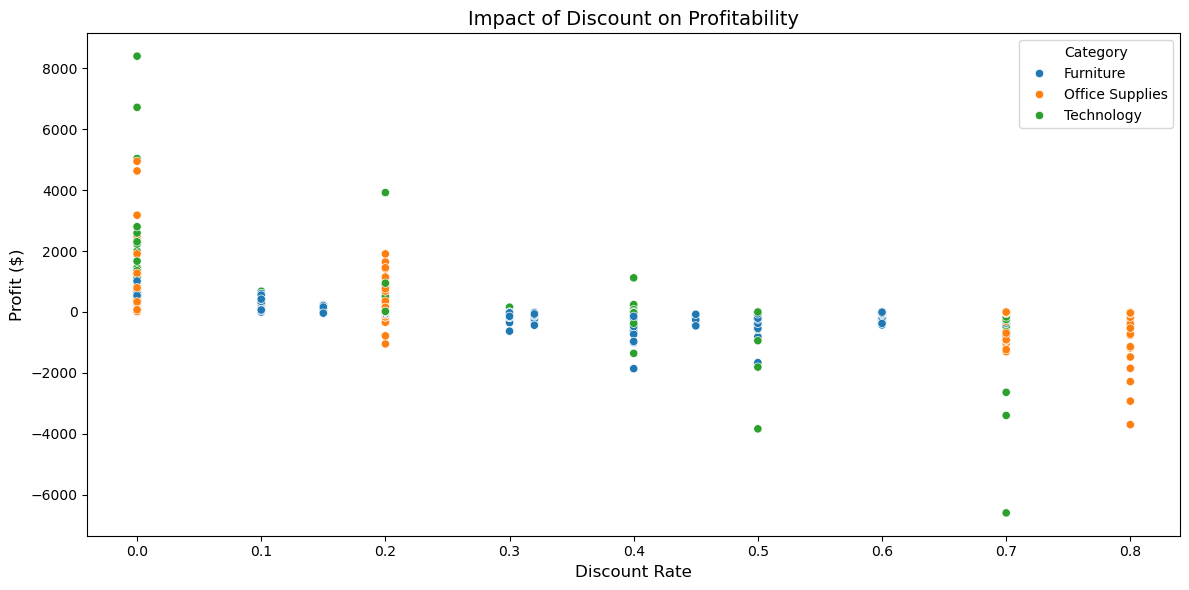

In [98]:
# Visualize the impact of Discount on Profit

plt.figure(figsize=(12,6))

sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category')
plt.title('Impact of Discount on Profitability', fontsize=14)
plt.xlabel('Discount Rate', fontsize=12)
plt.ylabel('Profit ($)', fontsize=12)

plt.tight_layout()
plt.show()


**Analysis:** <br>
The scatterplot clearly illustrates the severe negative impact of discounts on profitability. While low or zero discounts maintain positive profit margins, any discount above 20% (0.2) drastically pushes transactions into a loss. Furthermore, the visual highlights that the most extreme discount levels (up to 80%) are predominantly applied to the Office Supplies category.

In [100]:
# Check for Processing Order Time
df['Shipping_Days'] = df['Ship Date'] - df['Order Date']

# Check for Values
df['Shipping_Days'].value_counts()

Shipping_Days
4 days    2774
5 days    2169
2 days    1334
6 days    1203
3 days    1005
7 days     621
0 days     519
1 days     369
Name: count, dtype: int64

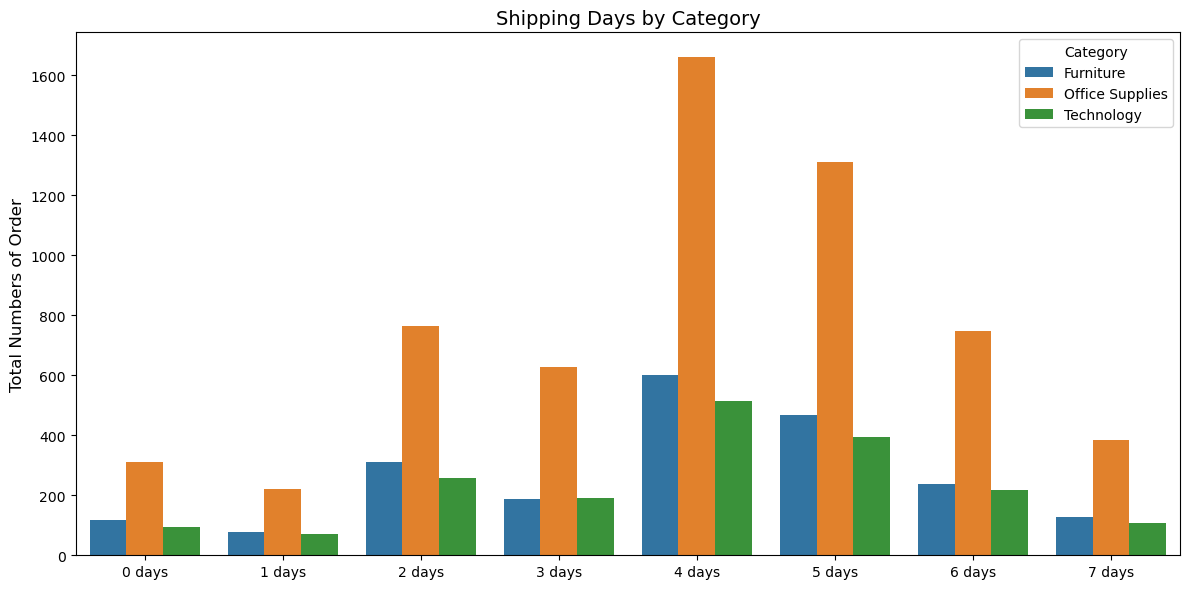

In [101]:
# Visualize the Shipping Days
plt.figure(figsize=(12,6))

days_order = ['0 days', '1 days', '2 days', '3 days', '4 days', '5 days', '6 days', '7 days']

sns.countplot(data=df, x='Shipping_Days', hue='Category', order=days_order)
plt.title('Shipping Days by Category', fontsize=14)
plt.xlabel('')
plt.ylabel('Total Numbers of Order', fontsize=12)

plt.tight_layout()
plt.show()